In [108]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [109]:
import pandas as pd
import numpy as np
print("Libraries imported ✓")


Libraries imported ✓


In [110]:
file_path = '/content/drive/MyDrive/CIS450_LendingClub_Project/lending_club_accepted_loans.csv'

In [111]:
dtype_dict = {
    'loan_amnt': 'float32',
    'funded_amnt': 'float32',
    'int_rate': 'float32',
    'annual_inc': 'float32',
    'dti': 'float32',
    'fico_range_low': 'float32',
    'fico_range_high': 'float32',
    'delinq_2yrs': 'int8',
    'inq_last_6mths': 'int8',
    'open_acc': 'int8',
    'pub_rec': 'int8',
    'revol_util': 'float32',
    'total_pymnt': 'float32',
    'loan_status': 'category',
    'grade': 'category',
    'sub_grade': 'category',
    'home_ownership': 'category',
    'verification_status': 'category',
    'purpose': 'category',
    'addr_state': 'category',
    'issue_d': 'string',          # we will turn this into date later
    'earliest_cr_line': 'string'
}


In [112]:
usecols = list(dtype_dict.keys())

print("Ready to load data...")


Ready to load data...


In [113]:
dtype_dict_for_loading = dtype_dict.copy()
for col in ['delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec']:
    dtype_dict_for_loading[col] = 'float32'

df_sample = pd.read_csv(
    file_path,
    usecols=usecols,
    dtype=dtype_dict_for_loading,
    low_memory=False,
    skiprows=lambda i: i>0 and np.random.rand() > 0.05
)
print('Sample dataset completed')

Sample dataset completed


In [114]:
df_sample.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112280 entries, 0 to 112279
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   loan_amnt            112277 non-null  float32 
 1   funded_amnt          112277 non-null  float32 
 2   int_rate             112277 non-null  float32 
 3   grade                112277 non-null  category
 4   sub_grade            112277 non-null  category
 5   home_ownership       112277 non-null  category
 6   annual_inc           112277 non-null  float32 
 7   verification_status  112277 non-null  category
 8   issue_d              112277 non-null  string  
 9   loan_status          112277 non-null  category
 10  purpose              112277 non-null  category
 11  addr_state           112277 non-null  category
 12  dti                  112180 non-null  float32 
 13  delinq_2yrs          112274 non-null  float32 
 14  earliest_cr_line     112274 non-null  string  
 15  

In [115]:
df_sample.head()

,loan_amnt,funded_amnt,int_rate,grade,sub_grade,home_ownership,annual_inc,verification_status,issue_d,loan_status,...,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_util,total_pymnt
0,25000.0,25000.0,7.49,A,A4,MORTGAGE,109000.0,Not Verified,Dec-2015,Fully Paid,...,26.020000,0.0,Dec-2001,745.0,749.0,1.0,9.0,0.0,54.299999,26224.230469
1,25000.0,25000.0,13.99,C,C4,MORTGAGE,79000.0,Not Verified,Dec-2015,Charged Off,...,34.529999,0.0,Jun-2001,730.0,734.0,1.0,33.0,0.0,18.600000,14490.919922
2,27500.0,27500.0,14.85,C,C5,MORTGAGE,195000.0,Not Verified,Dec-2015,Fully Paid,...,6.790000,0.0,Jul-2001,700.0,704.0,0.0,14.0,0.0,50.900002,29753.169922
3,20000.0,20000.0,14.85,C,C5,RENT,110000.0,Not Verified,Dec-2015,Fully Paid,...,12.450000,0.0,Jun-2007,690.0,694.0,0.0,8.0,0.0,84.500000,24889.013672
4,16000.0,16000.0,13.99,C,C4,MORTGAGE,142000.0,Verified,Dec-2015,Current,...,17.740000,2.0,Oct-2004,680.0,684.0,2.0,15.0,2.0,39.900002,14112.889648


In [116]:
df_sample.describe()


,loan_amnt,funded_amnt,int_rate,annual_inc,dti,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_util,total_pymnt
count,112277.000000,112277.000000,112277.000000,1.122770e+05,112180.000000,112274.000000,112277.000000,112277.000000,112274.000000,112274.000000,112274.000000,112187.000000,112277.000000
mean,15007.171875,15002.412109,13.083828,7.782766e+04,18.865828,0.309021,698.651611,702.651672,0.576625,11.622326,0.196368,50.284752,12040.716797
std,9202.390625,9200.199219,4.840116,8.041058e+04,14.273033,0.873263,33.039005,33.042267,0.887977,5.671389,0.551009,24.752098,9908.149414
min,550.000000,550.000000,5.310000,0.000000e+00,0.000000,0.000000,610.000000,614.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8000.000000,8000.000000,9.490000,4.600000e+04,11.900000,0.000000,675.000000,679.000000,0.000000,8.000000,0.000000,31.400000,4500.419922
50%,12800.000000,12800.000000,12.620000,6.500000e+04,17.820000,0.000000,690.000000,694.000000,0.000000,11.000000,0.000000,50.200001,9278.610352
75%,20000.000000,20000.000000,15.990000,9.300000e+04,24.530001,0.000000,715.000000,719.000000,1.000000,14.000000,0.000000,69.400002,16902.734375
max,40000.000000,40000.000000,30.990000,1.099920e+07,999.000000,27.000000,845.000000,850.000000,28.000000,86.000000,19.000000,138.899994,62663.617188


In [117]:
print(df_sample.shape)

(112280, 22)


In [118]:
missing = df_sample.isnull().sum().sort_values(ascending=False)
print('Top missing columns:\n',missing.head(15))

Top missing columns:
 dti                 100
revol_util           93
delinq_2yrs           6
earliest_cr_line      6
open_acc              6
inq_last_6mths        6
pub_rec               6
sub_grade             3
home_ownership        3
int_rate              3
funded_amnt           3
loan_amnt             3
grade                 3
annual_inc            3
purpose               3
dtype: int64


In [119]:
credit_cols = ['delinq_2yrs', 'earliest_cr_line', 'open_acc', 'inq_last_6mths', 'pub_rec']
df_sample = df_sample.dropna(subset=credit_cols)

In [120]:
df_sample['revol_util'] = df_sample['revol_util'].fillna(df_sample['revol_util'].median())

In [121]:
df_sample['dti'] = df_sample['dti'].fillna(df_sample['dti'].median())

In [122]:
print(df_sample[['dti', 'revol_util','delinq_2yrs', 'earliest_cr_line', 'open_acc', 'inq_last_6mths', 'pub_rec']].isnull().sum())

dti                 0
revol_util          0
delinq_2yrs         0
earliest_cr_line    0
open_acc            0
inq_last_6mths      0
pub_rec             0
dtype: int64


In [123]:
df_sample['issue_d'] = pd.to_datetime(df_sample['issue_d'], format='%b-%Y')
df_sample['year'] = df_sample['issue_d'].dt.year
df_sample['year'].value_counts().sort_index()

,count
year,
2007,26
2008,132
2009,234
2010,629
2011,1047
2012,2581
2013,6789
2014,11648
2015,20810


In [124]:
df_sample['loan_status'].value_counts(normalize=True)

,proportion
loan_status,
Fully Paid,0.475774
Current,0.388256
Charged Off,0.119208
Late (31-120 days),0.009735
In Grace Period,0.003679
Late (16-30 days),0.001977
Does not meet the credit policy. Status:Fully Paid,0.000989
Does not meet the credit policy. Status:Charged Off,0.000383


In [125]:
import seaborn as sns
import matplotlib.pyplot as plt

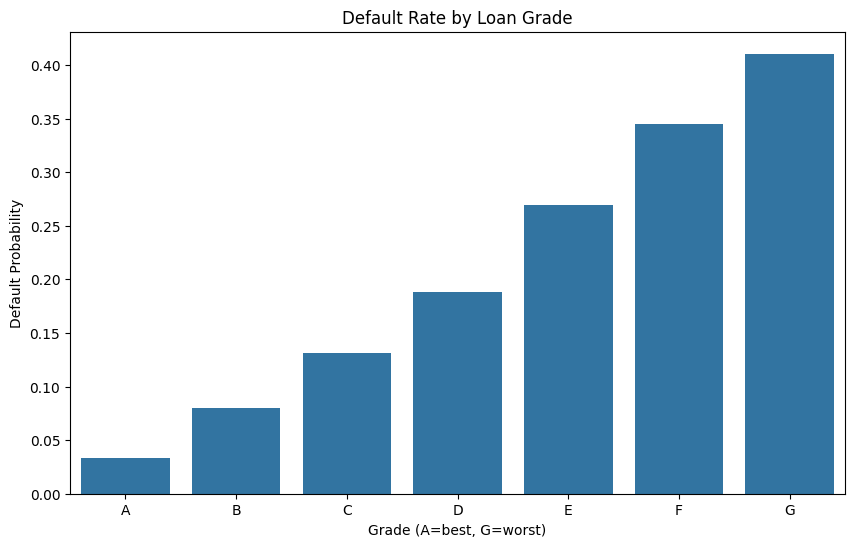

In [126]:
df_sample['is_default'] = df_sample['loan_status'].apply(lambda x: 1 if x in ['Charged Off', 'Default'] else 0)
plt.figure(figsize=(10,6))
sns.barplot(x='grade', y='is_default', data=df_sample, errorbar=None, order=sorted(df_sample['grade'].unique()))
plt.title('Default Rate by Loan Grade')
plt.ylabel('Default Probability')
plt.xlabel('Grade (A=best, G=worst)')
plt.show()

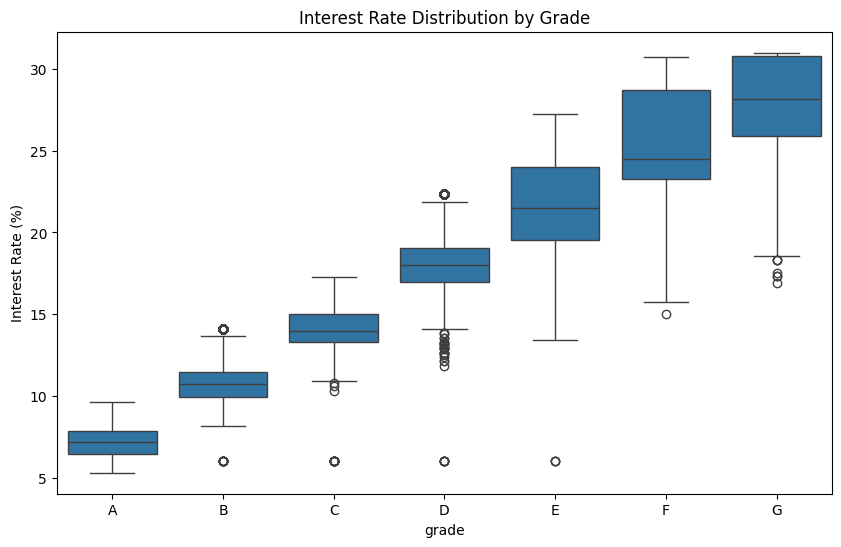

In [127]:
plt.figure(figsize=(10,6))
sns.boxplot(x='grade', y='int_rate', data=df_sample, order=sorted(df_sample['grade'].unique()))
plt.title('Interest Rate Distribution by Grade')
plt.ylabel('Interest Rate (%)')
plt.show()

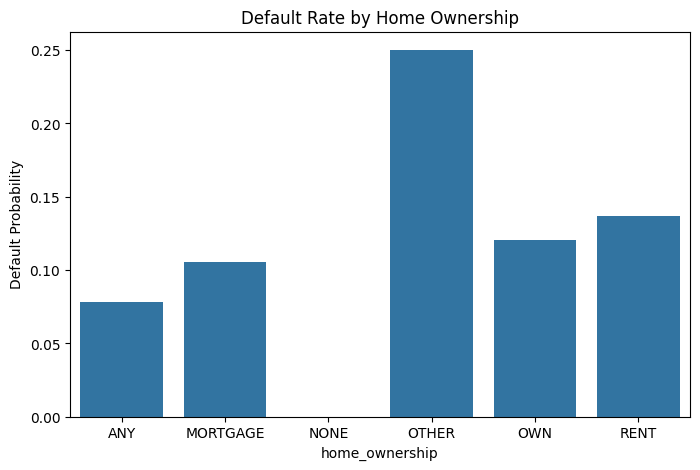

In [128]:
plt.figure(figsize=(8,5))
sns.barplot(x='home_ownership', y='is_default', data=df_sample, errorbar=None)
plt.title('Default Rate by Home Ownership')
plt.ylabel('Default Probability')
plt.show()

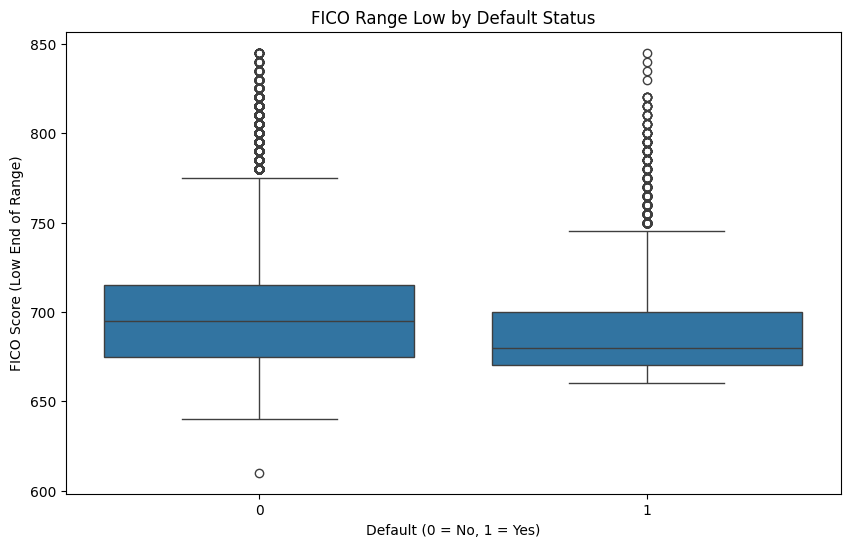

In [129]:
plt.figure(figsize=(10,6))
sns.boxplot(x='is_default', y='fico_range_low', data=df_sample)
plt.title('FICO Range Low by Default Status')
plt.ylabel('FICO Score (Low End of Range)')
plt.xlabel('Default (0 = No, 1 = Yes)')
plt.show()

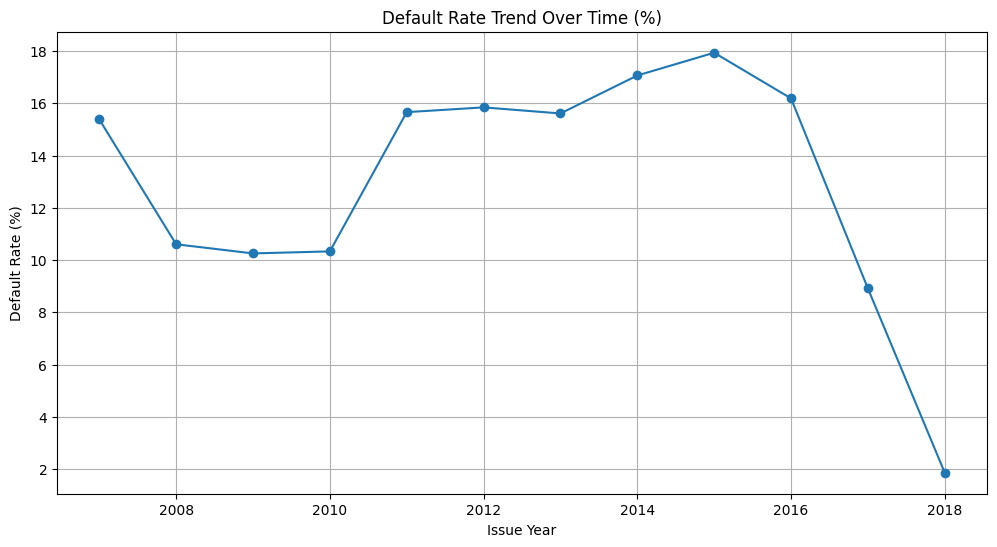

In [130]:
yearly_default = df_sample.groupby('year')['is_default'].mean() * 100

plt.figure(figsize=(12,6))
yearly_default.plot(kind='line', marker='o')
plt.title('Default Rate Trend Over Time (%)')
plt.ylabel('Default Rate (%)')
plt.xlabel('Issue Year')
plt.grid(True)
plt.show()

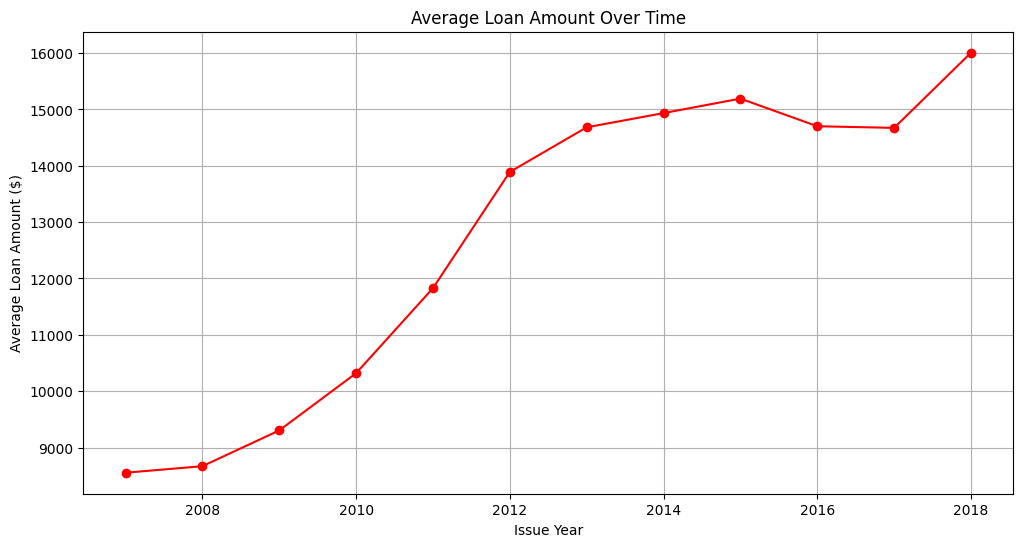

In [131]:
plt.figure(figsize=(12,6))
df_sample.groupby('year')['loan_amnt'].mean().plot(kind='line', marker='o', color='red')
plt.title('Average Loan Amount Over Time')
plt.ylabel('Average Loan Amount ($)')
plt.xlabel('Issue Year')
plt.grid(True)
plt.show()

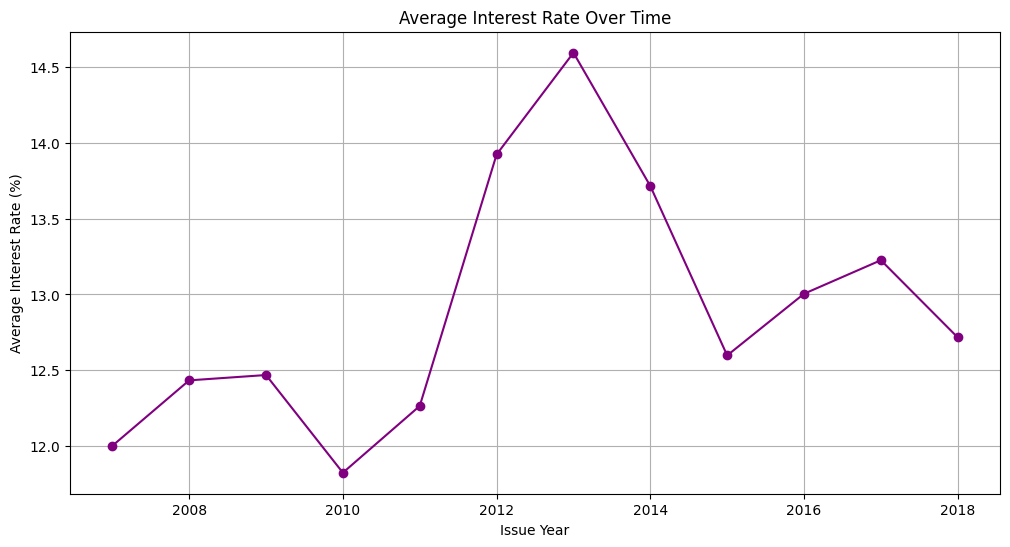

In [132]:
plt.figure(figsize=(12,6))
df_sample.groupby('year')['int_rate'].mean().plot(kind='line', marker='o', color='purple')
plt.title('Average Interest Rate Over Time')
plt.ylabel('Average Interest Rate (%)')
plt.xlabel('Issue Year')
plt.grid(True)
plt.show()

/tmp/ipykernel_919/2702107568.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_sample.groupby('purpose')['is_default'].mean().sort_values().plot(kind='barh', color='orange')


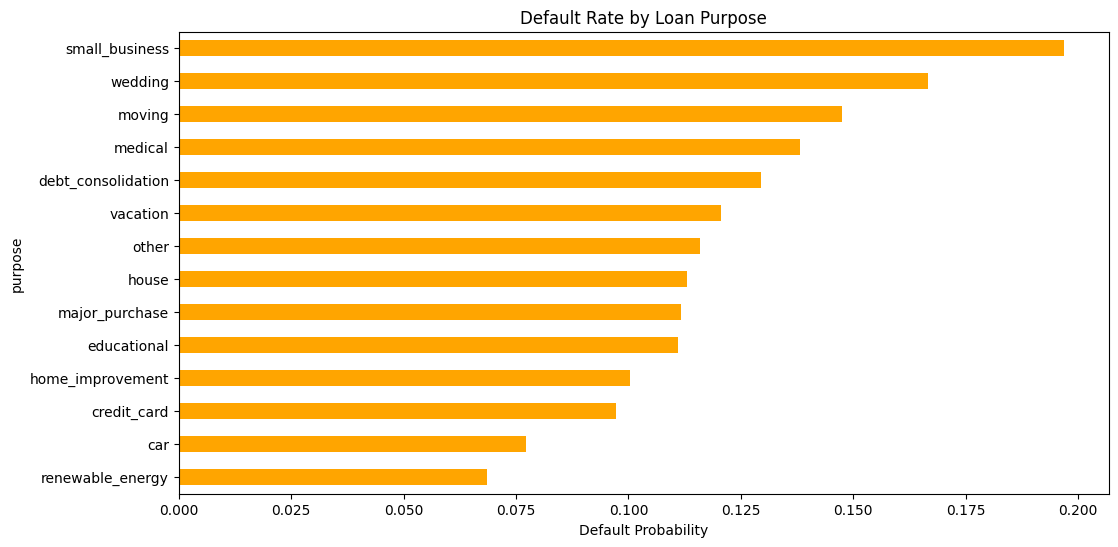

In [133]:
plt.figure(figsize=(12,6))
df_sample.groupby('purpose')['is_default'].mean().sort_values().plot(kind='barh', color='orange')
plt.title('Default Rate by Loan Purpose')
plt.xlabel('Default Probability')
plt.show()

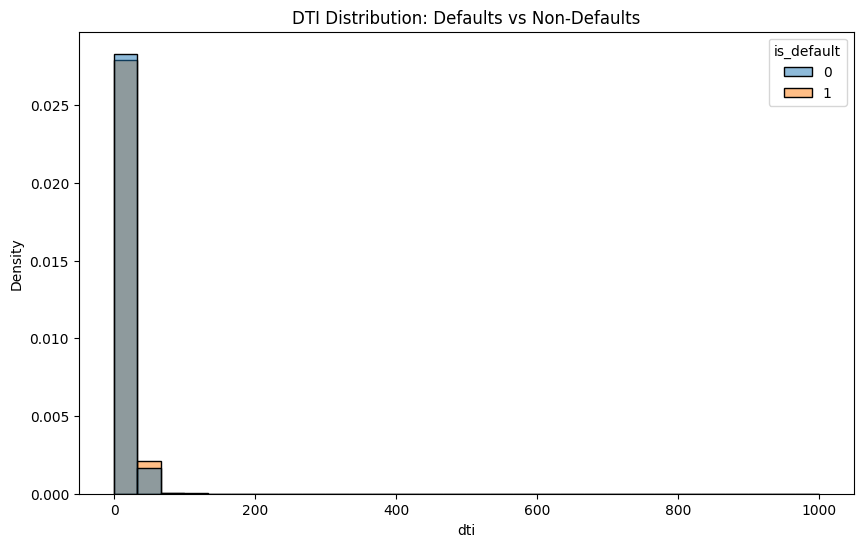

In [134]:
plt.figure(figsize=(10,6))
sns.histplot(data=df_sample, x='dti', hue='is_default', bins=30, stat='density', common_norm=False)
plt.title('DTI Distribution: Defaults vs Non-Defaults')
plt.show()

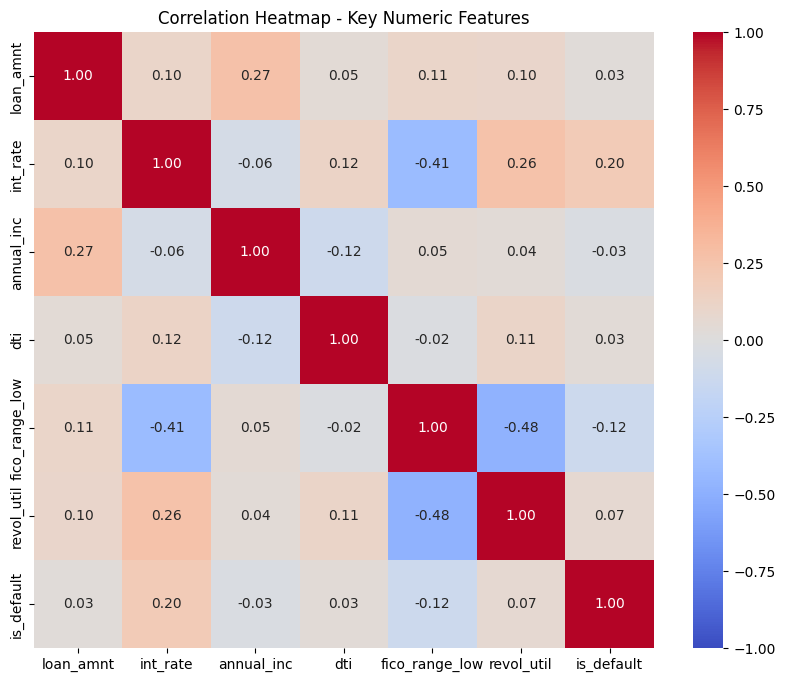

In [135]:
numeric_cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_range_low', 'revol_util', 'is_default']
corr_matrix = df_sample[numeric_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Heatmap - Key Numeric Features')
plt.show()